# Learned History Selection and Retrieval Fusion

This notebook trains four MiniLM history selectors from GPT-5.4 Teacher spans, selects the highest-MRR B64 architecture, and evaluates fusion across Recency, ROCC–IterCQR, and direct ROCC–BM25 retrieval views.

The selected three-epoch `collapsed_crf` checkpoint is the thesis base student $f_{\mathrm{base}}$. It reads the current query $q_t$ with the visible history $H_t$ and reconstructs the selected history $\widehat H_t$. The route names are $I$ (baseline rewriting), $R$ (selected-history rewriting), and $D$ (direct selected-history retrieval); $B$ is the complete rewriter-input budget, not the selector's 512-WordPiece window.


### Experimental setup

This cell initializes the complete NB05 environment and fixes the Python, NumPy, and PyTorch seeds to `13`. CUDA is selected when available, and B64 is defined as the primary comparison budget.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display


def resolve_project_root(start: Path) -> Path:
    configured = os.environ.get("ROCC_ROOT") or os.environ.get("MASTER_THESIS_PROJECT_ROOT")
    if configured:
        candidate = Path(configured).expanduser().resolve()
        if not (candidate / "experiments" / "rocc").is_dir():
            raise FileNotFoundError(f"Configured ROCC checkout is missing: {candidate}")
        return candidate
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "rocc").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Open this notebook from your ROCC checkout, or set ROCC_ROOT to it. "
        "In Colab, first clone the public repository over HTTPS or authenticate "
        "your own private checkout; no private clone or deploy key is assumed."
    )


PROJECT_ROOT = resolve_project_root(Path.cwd())
os.environ["MASTER_THESIS_PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.rocc import (
    FULL_CANDIDATE_ORDER,
    FULL_CANDIDATE_RECIPE_VERSION,
    SelectorExperimentConfig,
    build_selector_oracle_gate,
    compare_target_recall,
    compute_union_recall,
    evaluate_selector_fusions,
    load_selector_sources,
    predict_selector_histories,
    prepare_selector_datasets,
    run_full_selector_candidates,
    run_selector_direct_bm25,
    run_selector_retrieval_evaluation,
    select_full_selector_architecture,
    validate_selector_environment,
)


SEED = 13
RUN_FULL_TRAIN = True
PRIMARY_BUDGET = 64
LOSS_PLOT_UPDATE_EVERY = 50
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

RESULT_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "05_history_selector"
)
TEACHER_600_METRICS_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "results"
    / "04_teacher"
    / "teacher_600_metrics.csv"
)
TEACHER_600_METRICS_SHA256 = (
    "7a35183a6796a87ffa0354ffb4e3d39a"
    "606cfaca2707676d586308a47b908d8b"
)
SCORE_CACHE_DB = (
    PROJECT_ROOT
    / ".cache"
    / "master_thesis"
    / "05_history_selector"
    / "minmax_fusion_bm25_scores.sqlite3"
)

CONFIG = SelectorExperimentConfig(
    train_labels=(
        PROJECT_ROOT
        / "experiments"
        / "results"
        / "04_teacher"
        / "rocc_history_labels_topiocqa_train.jsonl"
    ),
    train_manifest=(
        PROJECT_ROOT
        / "experiments"
        / "results"
        / "04_teacher"
        / "rocc_history_labels_topiocqa_train.manifest.json"
    ),
    topiocqa_data_dir=(
        PROJECT_ROOT / "experiments" / "data" / "topiocqa"
    ),
    result_dir=RESULT_DIR,
    encoding_cache_dir=(
        PROJECT_ROOT
        / ".cache"
        / "master_thesis"
        / "05_history_selector"
    ),
    itercqr_model_dir=(
        PROJECT_ROOT
        / "experiments"
        / "model"
        / "IterCQR"
        / "IterCQR Model"
    ),
    bm25_index_dir=(
        PROJECT_ROOT
        / "experiments"
        / "data"
        / "pyserini_bm25_lucene_topiocqa"
        / "lucene_index"
    ),
    pipeline_cache_db=(
        PROJECT_ROOT
        / ".cache"
        / "master_thesis"
        / "03_oracle_headroom_analysis"
        / "runtime_cache.sqlite3"
    ),
    seed=SEED,
    full_epochs=3,
    retrieval_workers=max(
        1,
        min(8, (os.cpu_count() or 2) // 2),
    ),
)

# Historical hashes remain the default. ROCC_LINEAGE=local explicitly pins
# matching local upstream files; original method/population checks still run.
from experiments.rocc.paths import bind_notebook_lineage
from dataclasses import replace

local_inputs = bind_notebook_lineage(
    RESULT_DIR, "nb05", {
        "train": CONFIG.expected_train_sha256,
        "teacher600_metrics": TEACHER_600_METRICS_SHA256,
    }, {"train": CONFIG.train_labels, "teacher600_metrics": TEACHER_600_METRICS_PATH},
    manifest_fields=(("train", CONFIG.train_manifest, ("dataset_sha256",)),),
)
CONFIG = replace(CONFIG, expected_train_sha256=local_inputs["train"])
TEACHER_600_METRICS_SHA256 = local_inputs["teacher600_metrics"]

environment = validate_selector_environment(
    CONFIG,
    require_lora=False,
)
display(
    pd.DataFrame(
        [
            {
                **environment,
                "device": DEVICE,
                "run_full_train": RUN_FULL_TRAIN,
                "primary_budget": PRIMARY_BUDGET,
                "budgets": CONFIG.budgets,
                "full_epochs": CONFIG.full_epochs,
                "training_recipe": (
                    FULL_CANDIDATE_RECIPE_VERSION
                ),
            }
        ]
    )
)

,model_name,model_revision,max_position_embeddings,crf_backend,pytorch_crf_version,peft_version,device,run_full_train,primary_budget,budgets,full_epochs,training_recipe
0,sentence-transformers/all-MiniLM-L12-v2,a50ef00143b4d5391434df20ae11632588ac25be,512,pytorch-crf,0.7.2,None,cuda:0,True,64,"(64, 128, 256, 512)",3,independent_hf_full_v2


### Reconstruction of the 600-query sample

This cell loads the complete TopiOCQA training labels, conversation samples, and gold passage IDs. It then reconstructs the exact depth-balanced, conversation-disjoint 600-query sample used in NB03 and verifies its identity through the sample-ID SHA-256 hash.

The selected IDs align each Teacher record with its conversation history and retrieval gold labels. All four selector variants are therefore evaluated on the same queries under identical conditions.

Because these 600 queries are also included in the full training dataset, the evaluation scope is recorded as `train_member`. Evaluating a model on observations used during fitting corresponds to Efron’s *apparent error rate* and can yield an optimistically biased estimate of performance on unseen data [1]. The sample therefore supports controlled in-sample comparison among the four selector variants.

[1]: Efron, B. (1986). *How Biased Is the Apparent Error Rate of a Prediction Rule?* Journal of the American Statistical Association, 81(394), 461–470. [https://doi.org/10.1080/01621459.1986.10478291](https://doi.org/10.1080/01621459.1986.10478291)

In [2]:
sources = load_selector_sources(
    CONFIG,
    progress=True,
)
train600 = build_selector_oracle_gate(
    sources,
    CONFIG,
    progress=True,
)

train_row_by_id = {
    str(row["sample_id"]): row
    for row in sources["train_rows"]
}
train_sample_by_id = {
    str(sample.sample_id): sample
    for sample in sources["train_samples"]
}
train600_rows = [
    train_row_by_id[sample_id]
    for sample_id in train600.sample_ids
]
train600_samples = [
    train_sample_by_id[sample_id]
    for sample_id in train600.sample_ids
]
train600_gold = {
    sample_id: sources["train_gold_by_sample"][sample_id]
    for sample_id in train600.sample_ids
}
full_sample_ids = [
    str(row["sample_id"])
    for row in sources["train_rows"]
]

display(
    pd.DataFrame(
        [
            {
                "full_train_queries": len(full_sample_ids),
                "train600_queries": train600.query_count,
                "train600_conversations": (
                    train600.conversation_count
                ),
                "train600_sample_id_sha256": (
                    train600.sample_id_sha256
                ),
                "evaluation_scope": "train_member",
            }
        ]
    )
)

,full_train_queries,train600_queries,train600_conversations,train600_sample_id_sha256,evaluation_scope
0,38432,600,600,147e62c8a7f071356afd7da51dc2b61547837e321a43cb...,train_member


### Training representations and class balancing

The validated Teacher character spans are projected onto MiniLM subwords to create the supervision required for sequence tagging. The current query and canonical dialogue history are tokenized together, and offset mappings connect every history subword to the corresponding Teacher spans.

Two label spaces test different levels of supervision:

- `taxonomy` preserves six semantic classes: `O`, `ENTITY`, `CONCEPT`, `KEY_TERM`, `DEFINITION`, and `RELATION_CUE`.
- `collapsed` uses BIO (`Beginning`, `Inside`, `Outside`) selection labels, where `B-KEEP` marks the beginning of a newly matched retained span, `I-KEEP` marks its continuation, and `O` marks unselected history subwords. Overlapping Teacher spans contribute to the same KEEP coverage and do not create an additional boundary inside an active span.

For sample `train:3198:19`, the validated span `The Domesday Book` becomes `the/B-KEEP domesday/I-KEEP book/I-KEEP`, while the unselected prefix `Yes,` receives `O`. The nested `KEY_TERM` span `medieval Europe` remains part of the surrounding `DEFINITION` KEEP sequence and therefore creates no second `B-KEEP`.

Query, special, and padding tokens receive `-100` because selection applies only to the dialogue history. The `full` split contains all 38,432 training queries. `train600` retains the fixed in-sample monitoring set so that all four model variants are compared on the same queries during training.

Because `O` strongly dominates both label spaces, unweighted cross-entropy would favor predicting the majority class. Class weights are therefore calculated from the complete training split:

$$
\omega_c = \frac{N_{\mathrm{train}}}{|\mathcal Y|N_{\mathrm{train},c}}
$$

Here, $N_{\mathrm{train}}$ is the total number of supervised history WordPieces, $|\mathcal Y|$ is the number of target classes (6 or 3), and $N_{\mathrm{train},c}$ is the count for class $c$. This assigns each class the same total weight $N_{\mathrm{train}}/|\mathcal Y|$. Frequent classes receive smaller weights, while rare semantic and KEEP classes receive larger weights.

The weights modify each class’s contribution to token-level cross-entropy without resampling the data. CRF candidates later combine this weighted token loss with a length-normalized sequence loss.

In [3]:
prepared_full = prepare_selector_datasets(
    sources["train_rows"],
    {
        "full": full_sample_ids,
        "train600": train600.sample_ids,
    },
    CONFIG,
    class_weight_split="full",
    dataset_sha256=CONFIG.expected_train_sha256,
    label_spaces=("taxonomy", "collapsed"),
    progress=True,
)

weight_rows = []
for label_space in ("taxonomy", "collapsed"):
    stats = prepared_full[
        f"{label_space}_stats"
    ]["full"]
    weight_rows.append(
        {
            "label_space": label_space,
            "classes": len(
                prepared_full[
                    f"{label_space}_class_weights"
                ]
            ),
            "class_weights": [
                round(float(value), 4)
                for value in prepared_full[
                    f"{label_space}_class_weights"
                ]
            ],
            "history_tokens": stats.get(
                "history_tokens",
                stats.get("tokens"),
            ),
            "train_queries": len(
                prepared_full["rows_by_split"]["full"]
            ),
            "monitor_queries": len(
                prepared_full["rows_by_split"]["train600"]
            ),
        }
    )
display(pd.DataFrame(weight_rows))

,label_space,classes,class_weights,history_tokens,train_queries,monitor_queries
0,taxonomy,6,"[0.1822, 4.83, 78.5068, 67.9998, 4.776, 14.7741]",7791957,38432,600
1,collapsed,3,"[0.3644, 20.9791, 4.8052]",7791957,38432,600


Both label spaces are derived from the same 7,791,957 history subwords across all 38,432 training queries. The 600-query subset is reused only for in-sample monitoring and is not a held-out validation set.

The class weights follow the class-ID order:

- `taxonomy`: `O` = 0.1822, `ENTITY` = 4.8300, `CONCEPT` = 78.5068, `KEY_TERM` = 67.9998, `DEFINITION` = 4.7760, and `RELATION_CUE` = 14.7741.
- `collapsed`: `O` = 0.3644, `B-KEEP` = 20.9791, and `I-KEEP` = 4.8052.

They are calculated with $\omega_c=N_{\mathrm{train}}/(|\mathcal Y|N_{\mathrm{train},c})$ as explained above.

The low `O` weights compensate for the dominance of unselected history tokens. The large `CONCEPT`, `KEY_TERM`, and `RELATION_CUE` weights show that these taxonomy labels are comparatively rare. In the collapsed BIO space, `B-KEEP` receives a larger weight than `I-KEEP` because every selected span has only one beginning subword but may contain several continuation subwords. These weights balance the contribution of the classes to the training loss.

### Training-label distribution

The label-distribution plot visualizes the class imbalance behind the previously calculated weights. Each bar shows the share and absolute number of labeled history subwords in the complete TopiOCQA training set.

The taxonomy panel distinguishes `O`, `ENTITY`, `CONCEPT`, `KEY_TERM`, `DEFINITION`, and `RELATION_CUE`. The collapsed panel represents the same tokens as `O`, `B-KEEP`, and `I-KEEP`. Gray denotes dropped history tokens and orange denotes retained tokens. Comparing both representations shows how strongly `O` dominates and why inverse-frequency weighting is required during training.

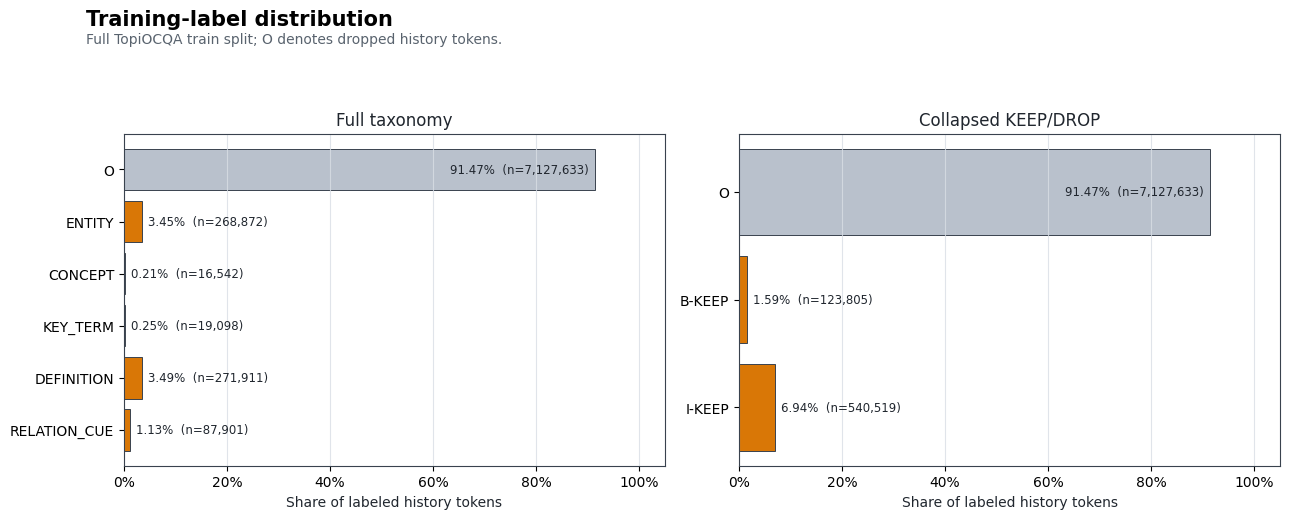

Plot: <project>/experiments/results/05_history_selector/class_distribution.png


In [4]:
from matplotlib.ticker import PercentFormatter

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#39424e",
        "axes.labelcolor": "#20262e",
        "axes.titlecolor": "#20262e",
        "grid.color": "#d9dee5",
        "grid.linewidth": 0.8,
        "font.size": 10,
    }
)

ORANGE = "#d97706"
GRAY = "#b9c1cc"
INK = "#20262e"
EDGE = "#39424e"

label_spaces = (
    ("taxonomy", "Full taxonomy"),
    ("collapsed", "Collapsed KEEP/DROP"),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.2),
)

for ax, (label_space, title) in zip(
    axes,
    label_spaces,
    strict=True,
):
    counts = pd.Series(
        prepared_full[
            f"{label_space}_stats"
        ]["full"]["label_counts"],
        dtype="int64",
    )
    shares = counts / counts.sum()

    bars = ax.barh(
        counts.index,
        shares,
        color=[
            GRAY if label == "O" else ORANGE
            for label in counts.index
        ],
        edgecolor=EDGE,
        linewidth=0.7,
    )

    for bar, count, share in zip(
        bars,
        counts,
        shares,
        strict=True,
    ):
        inside = share > 0.25
        ax.text(
            share - 0.012 if inside else share + 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{share:.2%}  (n={count:,})",
            ha="right" if inside else "left",
            va="center",
            color=INK,
            fontsize=8.5,
        )

    ax.set_xlim(0, 1.05)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(
        PercentFormatter(1.0)
    )
    ax.set_xlabel("Share of labeled history tokens")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.8)
    ax.grid(axis="y", visible=False)

fig.suptitle(
    "Training-label distribution",
    x=0.07,
    y=0.99,
    ha="left",
    fontsize=15,
    fontweight="bold",
)
fig.text(
    0.07,
    0.925,
    "Full TopiOCQA train split; O denotes dropped history tokens.",
    ha="left",
    color="#59636e",
)

fig.tight_layout(rect=(0, 0, 1, 0.89))

plot_path = RESULT_DIR / "class_distribution.png"
fig.savefig(
    plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Plot:", plot_path)


Only 8.53% of the 7,791,957 history subwords are retained, while 91.47% receive `O`. Within the taxonomy, `DEFINITION` and `ENTITY` account for most selected tokens. `CONCEPT` and `KEY_TERM` each represent less than 0.3%, which explains their particularly large class weights.

In the collapsed representation, 1.59% of all history subwords receive `B-KEEP` and 6.94% receive `I-KEEP`. The larger continuation share reflects that each selected span begins once but commonly extends across several subwords. The observed distribution confirms that unweighted training would be dominated by `O` predictions and motivates the inverse-frequency weighting.

### Training the four selector variants

Four mutually independent MiniLM variants are trained on all 38,432 Teacher-labeled queries for three epochs:

| Candidate | Label space | Decoder |
|---|---|---|
| `taxonomy_linear` | Six taxonomy classes | Linear |
| `collapsed_linear` | `O`, `B-KEEP`, `I-KEEP` | Linear |
| `taxonomy_crf` | Six taxonomy classes | CRF |
| `collapsed_crf` | `O`, `B-KEEP`, `I-KEEP` | CRF |

Every candidate starts from the same pinned MiniLM base checkpoint. All encoder and decoder parameters are then trained independently. No candidate inherits parameters from another candidate. The training data, initialization seed, optimizer configuration, and number of epochs remain fixed so that the comparison isolates the effects of the label space and decoder.

The linear models classify each history WordPiece independently using weighted cross-entropy $\mathcal L_{\mathrm{CE}}$. For one history with $r$ visible history tokens and target sequence $\mathbf y^\star$,

$$
\mathcal L_{\mathrm{CE}}
=-\frac{\sum_{j=1}^{r}\omega_{y_j^\star}
\log p_{\mathrm{lin}}(y_j=y_j^\star\mid\mathbf U)}
{\sum_{j=1}^{r}\omega_{y_j^\star}}.
$$

Here, $\mathbf U$ contains the MiniLM token representations. In minibatch training, the numerator and denominator are pooled over all supervised history tokens in the batch. The CRF sequence loss is the negative log-likelihood

$$
\mathcal L_{\mathrm{CRF}}
=-\log p_{\mathrm{CRF}}(\mathbf y^\star\mid\mathbf U)
=\log Z(\mathbf U)-F(\mathbf y^\star,\mathbf U),
$$

where $F$ is the complete sequence score and $Z$ is the partition function. The two training objectives, using the thesis notation, are

$$
\begin{aligned}
\text{Without CRF:}\quad &\mathcal L_{\mathrm{CE}},\\
\text{With CRF:}\quad &\mathcal L_{\mathrm{CE}}+\mathcal L_{\mathrm{CRF}}/r.
\end{aligned}
$$

Both terms have coefficient 1. The sequence loss is divided by each history's visible token count $r$ before averaging across the batch. This prevents longer histories from receiving a larger sequence-loss weight only because they contain more tokens.

MiniLM and the linear head produce emissions $e_j^H$. The CRF adds learned start scores $a^{\mathrm{start}}$, transitions $A_{c,c'}$, and end scores $a^{\mathrm{end}}$. Viterbi selects the highest-scoring complete sequence $\hat{\mathbf y}$, while linear decoding selects a label independently at each position. `taxonomy_crf` uses six semantic classes, while `collapsed_crf` uses $\mathcal Y=\{\mathrm O,\text{B-KEEP},\text{I-KEEP}\}$. Transition scores are not separately normalized probabilities, and no hard BIO constraint forbids an inconsistent transition. The history mask removes query, special, and padding positions before CRF scoring.

The combination of local and sequence losses follows the motivation of [Kumar and Basu (2025), *AdaBioBERT*](https://aclanthology.org/2025.bionlp-1.6/). Unlike its learned mixing weight, this experiment fixes both coefficients at 1, as specified in the thesis.

Because the four candidates use different label spaces and objectives, their absolute loss values are not directly comparable. The final epoch checkpoint is retained for each candidate. The architecture winner is selected later through the common B64 retrieval evaluation.

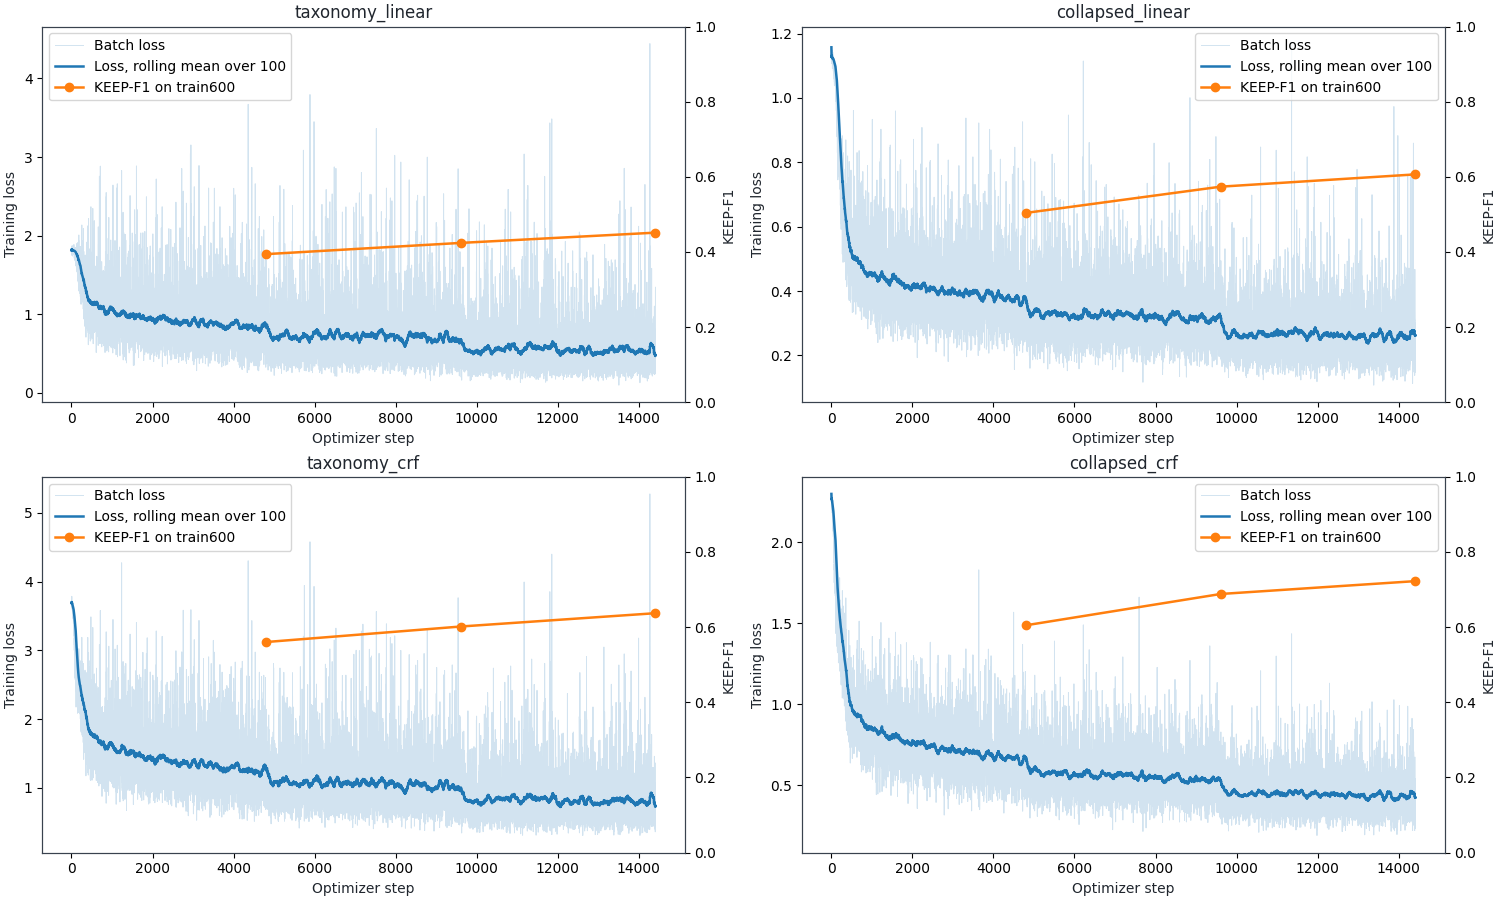

,arm,label_space,decoder,reused,epochs,final_train_loss,final_keep_f1,checkpoint,checkpoint_sha256,duration_seconds
0,taxonomy_linear,taxonomy,linear,True,3,0.548439,0.451337,/experiments/...,ef0f99f8800d4cd39ab28f88d23eed1ab4ad2f7883e013...,2475.555834
1,collapsed_linear,collapsed,linear,True,3,0.263298,0.606384,/experiments/...,ff9fc7f25cc74e13641047b08bc03dc5dcec9b83921ac7...,2306.938507
2,taxonomy_crf,taxonomy,crf,True,3,0.818310,0.637077,/experiments/...,31539f0ba4de0fdab299983a967fb2610994680849fbdd...,4741.363723
3,collapsed_crf,collapsed,crf,True,3,0.443611,0.722417,/experiments/...,a07271abefbc37ef08dba4eb94adb0e165f53a652060c0...,4550.401004


In [5]:
class FullTrainingDashboard:
    def __init__(self, candidate_order: tuple[str, ...]) -> None:
        self.candidate_order = candidate_order
        self.loss_rows = {
            arm: [] for arm in candidate_order
        }
        self.epoch_rows = {
            arm: [] for arm in candidate_order
        }
        self.figure, axes = plt.subplots(
            2,
            2,
            figsize=(15, 9),
            constrained_layout=True,
        )
        self.loss_axes = {
            arm: axis
            for arm, axis in zip(
                candidate_order,
                axes.ravel(),
                strict=True,
            )
        }
        self.f1_axes = {
            arm: self.loss_axes[arm].twinx()
            for arm in candidate_order
        }
        self.handle = display(
            self.figure,
            display_id=True,
        )
        for arm in candidate_order:
            self._draw(arm, update=False)
        self.handle.update(self.figure)

    def on_batch(
        self,
        arm: str,
        row: dict[str, Any],
    ) -> None:
        self.loss_rows[arm].append(dict(row))
        if int(row["batch"]) % LOSS_PLOT_UPDATE_EVERY == 0:
            self._draw(arm)

    def on_epoch(
        self,
        arm: str,
        row: dict[str, Any],
    ) -> None:
        self.epoch_rows[arm].append(dict(row))
        self._draw(arm)

    def load_history(
        self,
        arm: str,
        loss_history: pd.DataFrame,
        epoch_metrics: pd.DataFrame,
    ) -> None:
        self.loss_rows[arm] = loss_history.to_dict(
            orient="records"
        )
        self.epoch_rows[arm] = epoch_metrics.to_dict(
            orient="records"
        )
        self._draw(arm)

    def _draw(
        self,
        arm: str,
        *,
        update: bool = True,
    ) -> None:
        loss_axis = self.loss_axes[arm]
        f1_axis = self.f1_axes[arm]
        loss_axis.clear()
        f1_axis.clear()

        loss_frame = pd.DataFrame(self.loss_rows[arm])
        epoch_frame = pd.DataFrame(self.epoch_rows[arm])
        if not loss_frame.empty:
            loss_frame = loss_frame.sort_values(
                "global_step",
                kind="mergesort",
            )
            loss_axis.plot(
                loss_frame["global_step"],
                loss_frame["loss"],
                color="tab:blue",
                alpha=0.20,
                linewidth=0.7,
                label="Batch loss",
            )
            smoothed = (
                loss_frame["loss"]
                .rolling(100, min_periods=1)
                .mean()
            )
            loss_axis.plot(
                loss_frame["global_step"],
                smoothed,
                color="tab:blue",
                linewidth=1.8,
                label="Loss, rolling mean over 100",
            )

        if (
            not epoch_frame.empty
            and "keep_f1" in epoch_frame
        ):
            epoch_frame = epoch_frame.sort_values(
                "epoch",
                kind="mergesort",
            )
            if not loss_frame.empty:
                step_by_epoch = (
                    loss_frame.groupby("epoch")[
                        "global_step"
                    ].max()
                )
                f1_steps = [
                    int(step_by_epoch.loc[int(epoch)])
                    for epoch in epoch_frame["epoch"]
                ]
            else:
                f1_steps = epoch_frame[
                    "epoch"
                ].astype(int).tolist()
            f1_axis.plot(
                f1_steps,
                epoch_frame["keep_f1"],
                color="tab:orange",
                marker="o",
                linewidth=1.8,
                label="KEEP-F1 on train600",
            )

        loss_axis.set_title(arm)
        loss_axis.set_xlabel("Optimizer step")
        loss_axis.set_ylabel("Training loss")
        f1_axis.set_ylabel("KEEP-F1")
        f1_axis.set_ylim(0.0, 1.0)
        handles_left, labels_left = (
            loss_axis.get_legend_handles_labels()
        )
        handles_right, labels_right = (
            f1_axis.get_legend_handles_labels()
        )
        if handles_left or handles_right:
            loss_axis.legend(
                handles_left + handles_right,
                labels_left + labels_right,
                loc="best",
            )
        if update:
            self.handle.update(self.figure)

    def save(self, path: Path) -> None:
        path.parent.mkdir(parents=True, exist_ok=True)
        self.figure.savefig(path, dpi=160)
        plt.close(self.figure)


if not RUN_FULL_TRAIN:
    raise RuntimeError(
        "The canonical NB05 run requires RUN_FULL_TRAIN=True."
    )

training_dashboard = FullTrainingDashboard(
    FULL_CANDIDATE_ORDER
)
candidate_runs = run_full_selector_candidates(
    prepared_full,
    CONFIG,
    monitor_split="train600",
    output_dir=RESULT_DIR / "full_candidates",
    device=DEVICE,
    batch_metrics_reporter=(
        training_dashboard.on_batch
    ),
    epoch_metrics_reporter=(
        training_dashboard.on_epoch
    ),
    history_reporter=(
        training_dashboard.load_history
    ),
    progress=True,
)
training_dashboard.save(
    RESULT_DIR
    / "full_candidates"
    / "training_loss_and_f1.png"
)

training_rows = []
for arm in FULL_CANDIDATE_ORDER:
    run = candidate_runs[arm]
    final_epoch = (
        run["epoch_metrics"]
        .sort_values("epoch", kind="mergesort")
        .iloc[-1]
    )
    training_rows.append(
        {
            "arm": arm,
            "label_space": run["label_space"],
            "decoder": run["decoder"],
            "reused": run["reused"],
            "epochs": CONFIG.full_epochs,
            "final_train_loss": float(
                final_epoch["train_loss"]
            ),
            "final_keep_f1": float(
                final_epoch["keep_f1"]
            ),
            "checkpoint": str(run["checkpoint"]),
            "checkpoint_sha256": (
                run["checkpoint_sha256"]
            ),
            "duration_seconds": (
                run["run"].duration_seconds
            ),
        }
    )
display(pd.DataFrame(training_rows))

All four candidates completed three epochs. `reused=True` indicates that the completed checkpoints and their recorded histories were loaded from disk instead of being trained again during this execution.

The rolling loss decreases for every candidate, while $F_1^{\mathrm{KEEP}}$ increases across the three epochs. The final in-sample $F_1^{\mathrm{KEEP}}$ values are 0.451 for `taxonomy_linear`, 0.606 for `collapsed_linear`, 0.637 for `taxonomy_crf`, and 0.722 for `collapsed_crf`. CRF decoding improves $F_1^{\mathrm{KEEP}}$ within both label spaces, and the collapsed BIO representation performs better than the full taxonomy with the same decoder.

These results measure agreement with Teacher KEEP/DROP targets on the 600-query training-member subset. They do not measure retrieval quality or out-of-sample generalization. In particular, the higher $F_1^{\mathrm{KEEP}}$ of `collapsed_crf` does not yet establish it as the final architecture.

The reported losses cannot be compared directly across all candidates because the label spaces differ and the CRF loss combines token-level cross-entropy with sequence-level negative log-likelihood. CRF training also takes approximately twice as long as linear training because it performs structured sequence scoring and decoding.

### Retrieval evaluation of the four selector candidates

$F_1^{\mathrm{KEEP}}$ measures Teacher imitation, not retrieval quality. Each trained checkpoint therefore predicts retained history spans for the same 600 queries. Non-`O` taxonomy tags and collapsed `B-KEEP` or `I-KEEP` tags are projected back to exact history substrings and saved as reproducible JSONL files.

The four selector histories are compared with Recency at B64, B128, B256, and B512. Every arm uses the same frozen IterCQR rewriter, BM25 index, and gold passages. The resulting MRR, nDCG@3, $\mathrm{Recall}@10$, $\mathrm{Recall}@100$, and $\mathrm{Recall}@1000$ differences therefore isolate the effect of history selection.

Query-level results are retained for paired comparisons, while the displayed table reports mean metrics by arm and budget. Since the 600 queries are part of the training set, this evaluation supports architecture selection but does not estimate generalization.

In [6]:
candidate_predictions = {}
for arm in FULL_CANDIDATE_ORDER:
    run = candidate_runs[arm]
    candidate_predictions[arm] = (
        predict_selector_histories(
            train600_rows,
            CONFIG,
            checkpoint=run["checkpoint"],
            label_space=run["label_space"],
            adaptation="full",
            decoder=run["decoder"],
            class_weights=run["class_weights"],
            output_path=(
                RESULT_DIR
                / "train600"
                / "predictions"
                / f"{arm}.jsonl"
            ),
            device=DEVICE,
            progress=True,
        )
    )

candidate_retrieval = run_selector_retrieval_evaluation(
    samples=train600_samples,
    selector_histories=candidate_predictions,
    gold_by_sample=train600_gold,
    config=CONFIG,
    output_dir=RESULT_DIR / "train600" / "retrieval",
    budgets=CONFIG.budgets,
    include_recency=True,
    include_query_only=False,
    persist_runtime_cache_stats=False,
    device=DEVICE,
    progress=True,
)
candidate_pipeline_results = candidate_retrieval[
    "evaluation"
].pipeline_results
display(
    candidate_retrieval["summary"]
    .sort_values(["budget", "arm"], kind="mergesort")
    .round(4)
)

,budget,arm,n,MRR,nDCG@3,R@10,R@100,R@1000
0,64,collapsed_crf,600,0.1656,0.1509,0.2850,0.5017,0.6817
1,64,collapsed_linear,600,0.1594,0.1446,0.2667,0.4933,0.6933
2,64,recency,600,0.1370,0.1287,0.2250,0.4067,0.5717
3,64,taxonomy_crf,600,0.1456,0.1261,0.2717,0.5000,0.6983
4,64,taxonomy_linear,600,0.1563,0.1465,0.2483,0.4600,0.6433
5,128,collapsed_crf,600,0.1641,0.1497,0.2850,0.5167,0.7033
6,128,collapsed_linear,600,0.1644,0.1486,0.2633,0.5267,0.7267
7,128,recency,600,0.1670,0.1542,0.2650,0.4817,0.6600
8,128,taxonomy_crf,600,0.1512,0.1322,0.2750,0.5217,0.7217
9,128,taxonomy_linear,600,0.1723,0.1607,0.2817,0.4883,0.7017


At the primary B64 budget, `collapsed_crf` achieves the highest MRR at 0.16564 compared with 0.13702 for Recency. This corresponds to a descriptive gain of +0.02863 MRR or 20.9%. It also provides the highest B64 nDCG@3 and $\mathrm{Recall}@10$.

At B128, `taxonomy_linear` achieves the highest MRR at 0.1723. Recency becomes strongest at B256 and B512 as the larger budgets preserve more of the complete history.

Most selector results remain unchanged from B128 onward because their predicted histories already fit within the available budget. The selectors therefore represent a fixed compression regime, while Recency continues to benefit from additional input capacity. These are in-sample mean results. Final architecture selection requires the following paired B64 comparison.

### Budget-dependent retrieval comparison

The grouped bar chart compares mean MRR for Recency and the four selector candidates across B64, B128, B256, and B512. Blue represents taxonomy models, orange represents collapsed models, and opacity distinguishes linear from CRF decoding.

The visualization highlights the B64 advantage of learned compression and the increasing benefit of Recency at larger budgets. Selector performance largely saturates once the predicted history fits within the input limit, while Recency continues to gain from additional context.

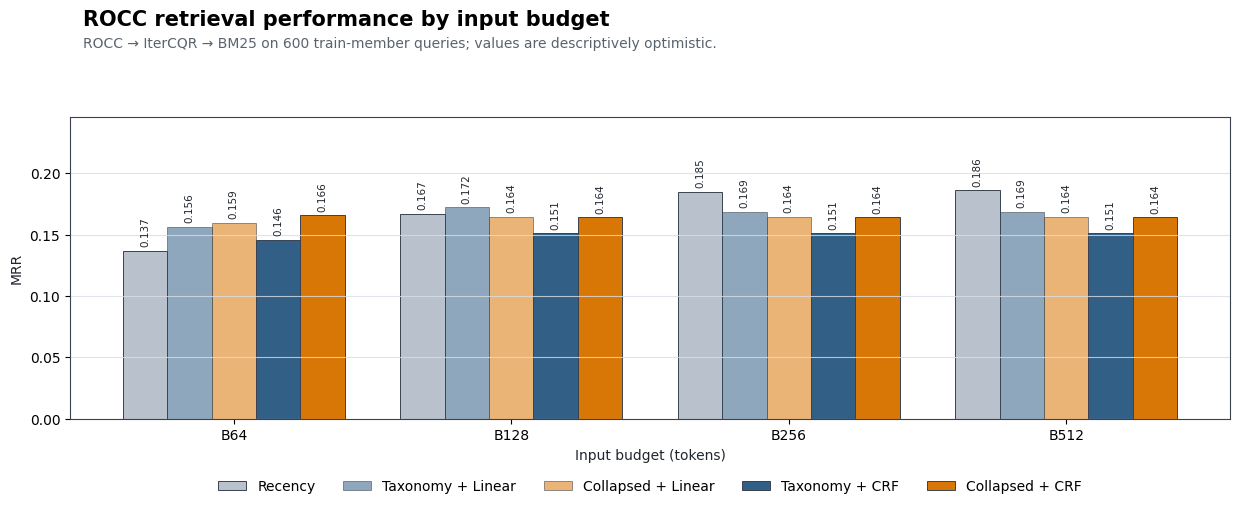

Plot: <project>/experiments/results/05_history_selector/train600/retrieval/mrr_by_budget.png


In [7]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#39424e",
        "axes.labelcolor": "#20262e",
        "axes.titlecolor": "#20262e",
        "grid.color": "#d9dee5",
        "grid.linewidth": 0.8,
        "font.size": 10,
    }
)

BLUE = "#315f86"
ORANGE = "#d97706"
GRAY = "#b9c1cc"
EDGE = "#39424e"
INK = "#20262e"

arm_styles = (
    ("recency", "Recency", GRAY, 1.0),
    (
        "taxonomy_linear",
        "Taxonomy + Linear",
        BLUE,
        0.55,
    ),
    (
        "collapsed_linear",
        "Collapsed + Linear",
        ORANGE,
        0.55,
    ),
    (
        "taxonomy_crf",
        "Taxonomy + CRF",
        BLUE,
        1.0,
    ),
    (
        "collapsed_crf",
        "Collapsed + CRF",
        ORANGE,
        1.0,
    ),
)

plot_data = candidate_retrieval["summary"].copy()
budget_order = [int(budget) for budget in CONFIG.budgets]
x = np.arange(len(budget_order))
bar_width = 0.16

fig, ax = plt.subplots(figsize=(12.5, 5.8))

for arm_index, (arm, label, color, alpha) in enumerate(
    arm_styles
):
    values = (
        plot_data.loc[plot_data["arm"].eq(arm)]
        .set_index("budget")
        .reindex(budget_order)["MRR"]
        .to_numpy(dtype=float)
    )
    offset = (
        arm_index - (len(arm_styles) - 1) / 2
    ) * bar_width

    bars = ax.bar(
        x + offset,
        values,
        width=bar_width,
        color=color,
        alpha=alpha,
        edgecolor=EDGE,
        linewidth=0.7,
        label=label,
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.3f}" for value in values],
        padding=3,
        fontsize=7.5,
        color=INK,
        rotation=90,
    )

ax.set_xticks(
    x,
    [f"B{budget}" for budget in budget_order],
)
ax.set_xlabel("Input budget (tokens)")
ax.set_ylabel("MRR")
ax.set_ylim(
    0,
    float(plot_data["MRR"].max()) * 1.32,
)
ax.grid(axis="y", alpha=0.8)
ax.grid(axis="x", visible=False)

fig.suptitle(
    "ROCC retrieval performance by input budget",
    x=0.07,
    y=0.99,
    ha="left",
    fontsize=15,
    fontweight="bold",
)
fig.text(
    0.07,
    0.925,
    (
        "ROCC → IterCQR → BM25 on 600 train-member "
        "queries; values are descriptively optimistic."
    ),
    ha="left",
    color="#59636e",
)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=5,
)

fig.tight_layout(rect=(0, 0.08, 1, 0.89))

plot_path = (
    RESULT_DIR
    / "train600"
    / "retrieval"
    / "mrr_by_budget.png"
)
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Plot:", plot_path)

### Architecture selection and Teacher anchor

The architecture is selected by the highest unrounded B64 MRR across the four candidates. All candidates must contain the same 600 queries and match the fixed Notebook 03 sample hash. Exact ties follow the predefined candidate order.

The winner is compared with every alternative through 10,000 paired query-level bootstrap draws. These intervals describe the uncertainty of the MRR differences but do not alter the selection rule. The selected checkpoint hash, summaries, comparisons, and locked decision are persisted for reproducibility.

The frozen Notebook 04 export then provides a descriptive Recency → Teacher → Student comparison. Its SHA-256, query count, and Recency result are verified before use. The Teacher result does not influence architecture selection. It only shows how closely the selected student approaches the Teacher’s retrieval performance on the same training-member queries.

In [8]:
architecture = select_full_selector_architecture(
    candidate_pipeline_results,
    candidate_runs,
    CONFIG,
    budget=PRIMARY_BUDGET,
    vehicle_sample_id_sha256=(
        train600.sample_id_sha256
    ),
    output_dir=(
        RESULT_DIR
        / "train600"
        / "architecture"
    ),
    progress=True,
)
choice = architecture["choice"]

display(
    architecture["summary"].loc[
        architecture["summary"]["budget"].eq(
            PRIMARY_BUDGET
        )
    ].round(4)
)
display(architecture["comparisons"].round(4))
display(
    pd.DataFrame(
        [
            {
                "selected_arm": choice.arm,
                "label_space": choice.label_space,
                "decoder": choice.decoder,
                "budget": choice.budget,
                "MRR": choice.mrr,
                "checkpoint_sha256": (
                    choice.checkpoint_sha256
                ),
                "evaluation_scope": "train_member",
            }
        ]
    )
)


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(1024 * 1024):
            digest.update(chunk)
    return digest.hexdigest()


if (
    sha256_file(TEACHER_600_METRICS_PATH)
    != TEACHER_600_METRICS_SHA256
):
    raise RuntimeError(
        "The frozen Teacher metric export has changed."
    )

teacher_table = pd.read_csv(TEACHER_600_METRICS_PATH)
teacher_row = teacher_table.loc[
    teacher_table["budget"].eq(PRIMARY_BUDGET)
    & teacher_table["arm"].eq("teacher")
    & teacher_table["row_type"].eq("arm")
].iloc[0]
teacher_recency_row = teacher_table.loc[
    teacher_table["budget"].eq(PRIMARY_BUDGET)
    & teacher_table["arm"].eq("recency")
    & teacher_table["row_type"].eq("arm")
].iloc[0]
if int(teacher_row["n"]) != train600.query_count:
    raise RuntimeError("Teacher anchor does not use n=600.")

summary_b64 = architecture["summary"].loc[
    architecture["summary"]["budget"].eq(
        PRIMARY_BUDGET
    )
]
recency_mrr = float(
    summary_b64.loc[
        summary_b64["arm"].eq("recency"),
        "MRR",
    ].iloc[0]
)
if not np.isclose(
    recency_mrr,
    float(teacher_recency_row["MRR"]),
):
    raise RuntimeError(
        "The Recency anchor from NB04 and the current run differ."
    )
teacher_mrr = float(teacher_row["MRR"])
student_mrr = float(choice.mrr)
descriptive_teacher_anchor = pd.DataFrame(
    [
        {
            "route": "Recency",
            "MRR": recency_mrr,
            "delta_to_previous": np.nan,
        },
        {
            "route": "Teacher",
            "MRR": teacher_mrr,
            "delta_to_previous": (
                teacher_mrr - recency_mrr
            ),
        },
        {
            "route": "Full-Train-Student",
            "MRR": student_mrr,
            "delta_to_previous": (
                student_mrr - teacher_mrr
            ),
        },
    ]
)
anchor_path = (
    RESULT_DIR
    / "train600"
    / "architecture"
    / "descriptive_teacher_anchor.csv"
)
descriptive_teacher_anchor.to_csv(
    anchor_path,
    index=False,
    float_format="%.17g",
    lineterminator="\n",
)
display(descriptive_teacher_anchor.round(4))
display(
    Markdown(
        "**Descriptive train-member anchor:** "
        f"Recency {recency_mrr:.4f} → "
        f"Teacher {teacher_mrr:.4f} → "
        f"Student {student_mrr:.4f}. "
        "The Teacher did not influence architecture selection."
    )
)

,budget,arm,n,MRR,nDCG@3,R@10,R@100,R@1000
0,64,collapsed_crf,600,0.1656,0.1509,0.2850,0.5017,0.6817
1,64,collapsed_linear,600,0.1594,0.1446,0.2667,0.4933,0.6933
2,64,recency,600,0.1370,0.1287,0.2250,0.4067,0.5717
3,64,taxonomy_crf,600,0.1456,0.1261,0.2717,0.5000,0.6983
4,64,taxonomy_linear,600,0.1563,0.1465,0.2483,0.4600,0.6433


,budget,metric,comparison,left_arm,right_arm,n,delta,ci95_low,ci95_high,seed,replicates
0,64,MRR,collapsed_crf - taxonomy_linear,collapsed_crf,taxonomy_linear,600,0.0093,-0.0113,0.0296,13,10000
1,64,MRR,collapsed_crf - collapsed_linear,collapsed_crf,collapsed_linear,600,0.0062,-0.0113,0.0239,14,10000
2,64,MRR,collapsed_crf - taxonomy_crf,collapsed_crf,taxonomy_crf,600,0.0201,0.0038,0.0367,15,10000


,selected_arm,label_space,decoder,budget,MRR,checkpoint_sha256,evaluation_scope
0,collapsed_crf,collapsed,crf,64,0.165642,a07271abefbc37ef08dba4eb94adb0e165f53a652060c0...,train_member


,route,MRR,delta_to_previous
0,Recency,0.1370,NaN
1,Teacher,0.1704,0.0333
2,Full-Train-Student,0.1656,-0.0047


**Descriptive train-member anchor:** Recency 0.1370 → Teacher 0.1704 → Student 0.1656. The Teacher did not influence architecture selection.

The base student $f_{\mathrm{base}}$ (`collapsed_crf`) is selected because it has the highest unrounded B64 MRR at 0.1656. Its descriptive gain over Recency is +0.02863 MRR or 20.9%.

The paired bootstrap distinguishes `collapsed_crf` from `taxonomy_crf` with a mean difference of +0.02009 and a 95% CI of [+0.00376, +0.03675]. Its differences from `taxonomy_linear` and `collapsed_linear` are positive but their confidence intervals contain 0. The winner is therefore selected by the predefined highest-MRR rule, not by demonstrating superiority over every alternative.

The Teacher reaches 0.17035 MRR and the selected student reaches 0.1656. The student is 0.00471 MRR below the Teacher while retaining approximately 86% of the Teacher’s descriptive improvement over Recency. All values are training-member results and do not estimate generalization.

### Recall as an indication of complementary retrieval views

The predefined B64 selection rule identifies `collapsed_crf` as the highest-MRR candidate among the four architectures independently trained on the complete training split.

The following analysis compares its `ROCC → IterCQR → BM25` recall with equal-budget Recency IterCQR at $\mathrm{Recall}@10$, $\mathrm{Recall}@100$, and $\mathrm{Recall}@1000$. Paired bootstrap intervals quantify the uncertainty of the query-level differences.

Recall differences indicate that ROCC changes the retrieved passage set. Complementarity is assessed through union recall and route-exclusive gold hits, which reveal whether Recency and ROCC recover relevant passages for different queries.

In [9]:
target_recall = compare_target_recall(
    pipeline_results=candidate_pipeline_results,
    target_arm=choice.arm,
    budget=PRIMARY_BUDGET,
    output_dir=RESULT_DIR / "train600" / "recall",
    replicates=CONFIG.bootstrap_replicates,
    progress=True,
)
display(target_recall["summary"].round(4))
display(target_recall["comparisons"].round(4))

,route,n,R@10,R@100,R@1000
0,I,600,0.225,0.4067,0.5717
1,R,600,0.285,0.5017,0.6817


,budget,metric,comparison,left_arm,right_arm,n,delta,ci95_low,ci95_high,seed,replicates
0,64,R@10,R - I,R,I,600,0.060,0.0250,0.0950,17,10000
1,64,R@100,R - I,R,I,600,0.095,0.0533,0.1367,18,10000
2,64,R@1000,R - I,R,I,600,0.110,0.0683,0.1517,19,10000


At B64, the selected ROCC route (`R`) retrieves gold passages more frequently than Recency IterCQR (`I`) at every cutoff. The gains are +6.0 percentage points at $\mathrm{Recall}@10$, +9.5 points at $\mathrm{Recall}@100$, and +11.0 points at $\mathrm{Recall}@1000$.

All paired 95% confidence intervals remain above 0, supporting a consistent recall advantage across the 600 training-member queries. The increasing difference at deeper cutoffs shows that ROCC expands gold-passage coverage beyond the top-ranked results. Union recall and route-exclusive hits next determine how much of this coverage is complementary to Recency.

### Union recall and route-exclusive hits

The cached B64 rankings from Recency IterCQR (`I`) and the selected ROCC route (`R`) are compared for the same 600 queries. At each cutoff, their retrieved passage sets are combined and evaluated against the gold passages.

Each query is assigned to `both`, `R_only`, `I_only`, or `neither` according to which route retrieves a gold passage. `union_recall` measures the coverage obtained from both sets together, while `union_gain_vs_best` quantifies the additional coverage beyond the stronger individual route.

Route-exclusive hits provide direct evidence of complementary retrieval behavior and establish the coverage available to the following fusion analysis.

In [10]:
union_recall = compute_union_recall(
    pipeline_results=candidate_pipeline_results,
    target_arm=choice.arm,
    budget=PRIMARY_BUDGET,
    gold_by_sample=train600_gold,
    config=CONFIG,
    output_dir=RESULT_DIR / "train600" / "union",
    device=DEVICE,
    vehicle_sample_id_sha256=(
        train600.sample_id_sha256
    ),
    cutoffs=(10, 100, 1000),
    progress=True,
)
display(union_recall["summary"].round(4))

,budget,cutoff,n,I_recall,R_recall,union_recall,union_gain_vs_best,both_count,both_share,R_only_count,R_only_share,I_only_count,I_only_share,neither_count,neither_share
0,64,10,600,0.2250,0.2850,0.3550,0.0700,93,0.1550,78,0.1300,42,0.0700,387,0.6450
1,64,100,600,0.4067,0.5017,0.5967,0.0950,187,0.3117,114,0.1900,57,0.0950,242,0.4033
2,64,1000,600,0.5717,0.6817,0.7683,0.0867,291,0.4850,118,0.1967,52,0.0867,139,0.2317


The two routes provide complementary gold-passage coverage at every cutoff. At rank 10, union recall reaches 0.3550, which is 7.0 percentage points above the stronger ROCC route. ROCC contributes 78 exclusive hits and Recency contributes another 42.

At rank 100, union recall increases to 0.5967 with a 9.5-point gain over ROCC alone. At rank 1000, the union covers 76.83% of queries and adds 8.67 points beyond the best individual route.

ROCC supplies more exclusive hits at every depth, while Recency consistently recovers additional queries missed by ROCC. These route-exclusive results establish a clear coverage opportunity for rank fusion.

### Direct ROCC–BM25 route

The direct route (`D`) loads the exact B64 token sequence produced for the selected ROCC history and decodes it back into text. This text contains the current query and retained history content after budget truncation.

The decoded input is submitted directly to BM25 without passing through the IterCQR rewriter. This isolates the lexical retrieval value of the selected content and creates a third ranking view with different behavior from Recency IterCQR (`I`) and ROCC IterCQR (`R`).

The same gold passages and retrieval metrics are used for evaluation. Cache statistics report how many distinct direct queries required new BM25 retrieval.

In [11]:
direct_route = run_selector_direct_bm25(
    pipeline_results=candidate_pipeline_results,
    selector_arm=choice.arm,
    budget=PRIMARY_BUDGET,
    gold_by_sample=train600_gold,
    config=CONFIG,
    output_dir=RESULT_DIR / "train600" / "fusion",
    device=DEVICE,
    progress=True,
)
display(direct_route["summary"].round(4))
display(
    pd.DataFrame(
        [direct_route["runtime_cache_stats"]]
    )
)

,arm,n,MRR,nDCG@3,R@10,R@100,R@1000
0,D,600,0.1445,0.1344,0.2467,0.4517,0.68


,unique_queries,retrieval_cache_misses,retriever_loaded
0,600,0,False


The direct ROCC–BM25 route reaches 0.1445 MRR. It performs above Recency IterCQR at 0.13702 but below ROCC IterCQR at 0.1656.

Its $\mathrm{Recall}@1000$ of 0.6800 is nearly identical to the ROCC IterCQR value of 0.6817 despite weaker early-ranking metrics. The selected lexical content therefore preserves substantial deep retrieval coverage while producing a distinct ranking view for fusion.

### Three-view rank fusion

The fusion combines the B64 rankings $L_I^{64}$, $L_R^{64}$, and $L_D^{64}$:

- `I`: Recency IterCQR
- `R`: ROCC IterCQR
- `D`: Direct ROCC–BM25

The notebook also retains `minmax_sum` as a development comparator; the thesis focuses on the RRF comparison. For `minmax_sum`, BM25 scores are normalized separately within every query and view:

$$
\widetilde{s}_v(d)
=
\frac{
s_v(d)-\min_{d'}s_v(d')
}{
\max_{d'}s_v(d')-\min_{d'}s_v(d')
}
$$

The three normalized scores are then added with equal weight:

$$
s_{\mathrm{MinMax}}(d)
=
\sum_{v\in\{I,R,D\}}
\widetilde{s}_v(d)
$$

This query-local normalization places the three BM25 score ranges on a common scale before aggregation.

`rrf10` and `rrf60` use only rank positions:

$$
\operatorname{RRF}_{\kappa}(d)
=\sum_{\substack{L\in\mathcal R\\d\in L}}
\frac{1}{\kappa+\operatorname{rank}_L(d)}
$$

Here, $\mathcal R$ contains the three participating route rankings, ranks start at 1, and only lists containing passage $d$ contribute. The smoothing parameter is $\kappa=10$ or $\kappa=60$ (`rrf_k` in code). The smaller value emphasizes top-ranked passages more strongly. This development comparison retains each route ranking, as in the thesis development figure.

All three methods are evaluated on the same 600 queries. Their pairwise MRR differences and gains over the strongest standalone view are quantified with 10,000 paired bootstrap draws.

The highest unrounded MRR selects the fusion method, with a fixed tie order.

In [13]:
fusion = evaluate_selector_fusions(
    pipeline_results=candidate_pipeline_results,
    direct_results=direct_route["evaluated"],
    target_arm=choice.arm,
    budget=PRIMARY_BUDGET,
    gold_by_sample=train600_gold,
    config=CONFIG,
    output_dir=RESULT_DIR / "train600" / "fusion",
    score_cache_db=SCORE_CACHE_DB,
    architecture_decision_path=(
        architecture["decision_path"]
    ),
    selector_checkpoint_sha256=(
        choice.checkpoint_sha256
    ),
    vehicle_sample_id_sha256=(
        train600.sample_id_sha256
    ),
    device=DEVICE,
    replicates=CONFIG.bootstrap_replicates,
    progress=True,
)
fusion_decision = fusion["decision"]

display(fusion["standalone_summary"].round(4))
display(fusion["fusion_summary"].round(4))
display(fusion["comparisons"].round(4))
display(pd.DataFrame([fusion_decision]))

,arm,n,MRR,nDCG@3,R@10,R@100,R@1000
0,D,600,0.1445,0.1344,0.2467,0.4517,0.6800
1,I,600,0.1370,0.1287,0.2250,0.4067,0.5717
2,R,600,0.1656,0.1509,0.2850,0.5017,0.6817


,arm,n,MRR,nDCG@3,R@10,R@100,R@1000
0,minmax_sum,600,0.1775,0.1574,0.3217,0.5567,0.7767
1,rrf10,600,0.1792,0.1628,0.3233,0.5683,0.7800
2,rrf60,600,0.1753,0.1588,0.3083,0.5767,0.7800


,budget,metric,comparison,left_arm,right_arm,n,delta,ci95_low,ci95_high,seed,replicates
0,64,MRR,minmax_sum - rrf10,minmax_sum,rrf10,600,-0.0017,-0.0085,0.0051,20,10000
1,64,MRR,minmax_sum - rrf60,minmax_sum,rrf60,600,0.0021,-0.0068,0.0114,21,10000
2,64,MRR,rrf10 - rrf60,rrf10,rrf60,600,0.0039,-0.0036,0.0112,22,10000
3,64,MRR,minmax_sum - R,minmax_sum,R,600,0.0118,-0.0027,0.0271,23,10000
4,64,MRR,rrf10 - R,rrf10,R,600,0.0135,-0.0001,0.0281,24,10000
5,64,MRR,rrf60 - R,rrf60,R,600,0.0097,-0.0067,0.0264,25,10000


,schema_version,locked,evaluation_scope,descriptive_only,budget,selection_metric,selection_rule,tie_break_order,selected_method,selected_parameters,selected_mrr,views,vehicle_sample_id_sha256,selector_checkpoint_sha256,architecture_decision_sha256,fusion_summary_sha256,bootstrap_replicates,bootstrap_seeds
0,1,True,train_member,False,64,MRR,highest_unrounded_MRR_then_fixed_order,"[minmax_sum, rrf10, rrf60]",rrf10,"{'rrf_k': 10, 'view_weights': {'I': 1.0, 'R': ...",0.179165,"[I, R, D]",147e62c8a7f071356afd7da51dc2b61547837e321a43cb...,a07271abefbc37ef08dba4eb94adb0e165f53a652060c0...,4794f16088d68d3e937d52b127fcb9433df5232bc9a146...,f2d8c8c83987310c18d46d020776d72bc3809e975b8cd9...,10000,"{'minmax_sum_minus_rrf10': 20, 'minmax_sum_min..."


`rrf10` achieves the highest unrounded MRR at 0.17916 and is selected by the predefined rule. Its descriptive gain over the strongest standalone route `R` is +0.01352 MRR or 8.2%. It also raises $\mathrm{Recall}@1000$ from 0.6817 to 0.7800.

All three fusion methods improve mean MRR and deep recall over the strongest individual route. `rrf60` provides the highest $\mathrm{Recall}@100$ at 0.5767, while `rrf10` provides the strongest MRR and nDCG@3.

The paired confidence intervals between fusion methods and relative to `R` all span 0. The locked decision therefore selects the strongest observed mean while preserving the uncertainty of the train-member comparison. The final rule uses equally weighted `I`, `R`, and `D` rankings with $\kappa=10$.

### Overall B64 retrieval comparison

The chart summarizes the three standalone routes and all three fusion methods on a common MRR scale. Every annotation reports the absolute MRR and its descriptive difference from Recency.

Gray represents Recency, blue represents individual ROCC routes, and orange represents fusion methods. The selected method is placed last and highlighted with hatching and a bold label.

Horizontal lines mark the Recency reference and the frozen Teacher anchor. The Teacher value provides context only and did not influence fusion selection. Statistical uncertainty is reported separately.

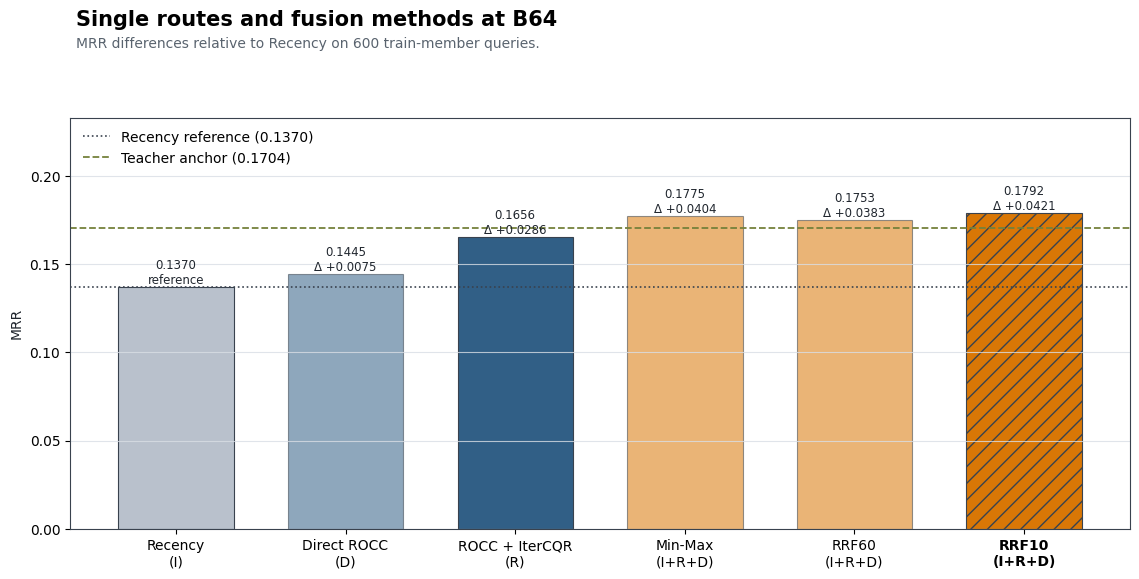

Plot: <project>/experiments/results/05_history_selector/train600/fusion/mrr_overall_b64.png


In [14]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#39424e",
        "axes.labelcolor": "#20262e",
        "axes.titlecolor": "#20262e",
        "grid.color": "#d9dee5",
        "grid.linewidth": 0.8,
        "font.size": 10,
    }
)

BLUE = "#315f86"
ORANGE = "#d97706"
GRAY = "#b9c1cc"
REFERENCE = "#75813b"
EDGE = "#39424e"
INK = "#20262e"

standalone_mrr = (
    fusion["standalone_summary"]
    .set_index("arm")["MRR"]
)
fusion_mrr = (
    fusion["fusion_summary"]
    .set_index("arm")["MRR"]
)

selected_method = fusion_decision["selected_method"]
fusion_order = [
    method
    for method in ("minmax_sum", "rrf10", "rrf60")
    if method != selected_method
] + [selected_method]

method_labels = {
    "I": "Recency\n(I)",
    "D": "Direct ROCC\n(D)",
    "R": "ROCC + IterCQR\n(R)",
    "minmax_sum": "Min-Max\n(I+R+D)",
    "rrf10": "RRF10\n(I+R+D)",
    "rrf60": "RRF60\n(I+R+D)",
}

plot_rows = [
    {
        "method": "I",
        "MRR": float(standalone_mrr["I"]),
        "color": GRAY,
        "alpha": 1.0,
        "selected": False,
    },
    {
        "method": "D",
        "MRR": float(standalone_mrr["D"]),
        "color": BLUE,
        "alpha": 0.55,
        "selected": False,
    },
    {
        "method": "R",
        "MRR": float(standalone_mrr["R"]),
        "color": BLUE,
        "alpha": 1.0,
        "selected": False,
    },
]

for method in fusion_order:
    plot_rows.append(
        {
            "method": method,
            "MRR": float(fusion_mrr[method]),
            "color": ORANGE,
            "alpha": (
                1.0 if method == selected_method else 0.55
            ),
            "selected": method == selected_method,
        }
    )

plot_frame = pd.DataFrame(plot_rows)
recency_reference = float(standalone_mrr["I"])
x = np.arange(len(plot_frame))

fig, ax = plt.subplots(figsize=(11.5, 5.8))

for index, row in plot_frame.iterrows():
    ax.bar(
        index,
        row["MRR"],
        width=0.68,
        color=row["color"],
        alpha=row["alpha"],
        edgecolor=EDGE,
        linewidth=0.8,
        hatch="//" if row["selected"] else None,
    )

    delta_label = (
        "reference"
        if row["method"] == "I"
        else f"Δ {row['MRR'] - recency_reference:+.4f}"
    )
    ax.text(
        index,
        row["MRR"],
        f"{row['MRR']:.4f}\n{delta_label}",
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=INK,
    )

ax.axhline(
    recency_reference,
    color=EDGE,
    linestyle=":",
    linewidth=1.2,
    label=f"Recency reference ({recency_reference:.4f})",
)
ax.axhline(
    teacher_mrr,
    color=REFERENCE,
    linestyle="--",
    linewidth=1.3,
    label=f"Teacher anchor ({teacher_mrr:.4f})",
)

ax.set_xticks(
    x,
    [
        method_labels[method]
        for method in plot_frame["method"]
    ],
)
for tick, selected in zip(
    ax.get_xticklabels(),
    plot_frame["selected"],
    strict=True,
):
    if selected:
        tick.set_fontweight("bold")

ax.set_ylabel("MRR")
ax.set_ylim(
    0,
    float(plot_frame["MRR"].max()) * 1.30,
)
ax.grid(axis="y", alpha=0.8)
ax.grid(axis="x", visible=False)
ax.legend(
    frameon=False,
    loc="upper left",
)

fig.suptitle(
    f"Single routes and fusion methods at B{PRIMARY_BUDGET}",
    x=0.07,
    y=0.99,
    ha="left",
    fontsize=15,
    fontweight="bold",
)
fig.text(
    0.07,
    0.925,
    (
        "MRR differences relative to Recency on "
        "600 train-member queries."
    ),
    ha="left",
    color="#59636e",
)

fig.tight_layout(rect=(0, 0, 1, 0.89))

plot_path = (
    RESULT_DIR
    / "train600"
    / "fusion"
    / f"mrr_overall_b{PRIMARY_BUDGET}.png"
)
plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(
    plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Plot:", plot_path)

## Conclusion

Notebook 05 converts the GPT-5.4 span labels into a query-conditioned MiniLM token selector. The selected `collapsed_crf` model achieves an MRR of 0.16564 at B64, compared with 0.13702 for Recency and 0.17035 for the Teacher. The student therefore retains approximately 86% of the Teacher improvement over Recency.

The selected ROCC route also improves recall at every cutoff. Combining its rankings with Recency increases $\mathrm{Recall}@1000$ from 0.6817 to 0.7683 because both routes retrieve exclusive relevant passages. The direct ROCC representation provides a third retrieval view. Their fixed RRF10 fusion achieves the highest observed MRR of 0.1792. Its paired difference from the best standalone route is not statistically resolved, so RRF10 is retained through the predefined highest-unrounded-MRR selection rule.

These results establish that the Teacher signal can be learned and converted into retrieval-relevant history selection. They remain descriptive because architecture and fusion selection use the same 600 train-member queries.

Notebook 06 addresses the remaining difference between label imitation and the downstream retrieval objective. Both post-training arms start independently from $f_{\mathrm{base}}$. The imitation control $f_{\mathrm{imit}}$ continues training on the original Teacher targets $\mathbf y^\star$, while the corrected-label student $f_{\mathrm{BM25}}$ learns targets $\mathbf y^\star_{\mathrm{BM25}}$ that additionally change Teacher-DROP tokens to KEEP when they provide positive, non-stopword BM25 evidence for the gold passage. This controlled comparison tests whether training-only lexical retrieval evidence can improve the learned CRF distribution beyond continued Teacher imitation.

## Result summary

These tables read the saved results of this notebook and display them directly, without a separate export. Rerun the preceding experiment cells first when generating new results.


In [4]:
from experiments.scripts.analysis_results import display_results

display_results(PROJECT_ROOT / "experiments", '05_history_selector')


**Student epoch means and training-member development F1**

,model,epoch,mean_training_loss,development_KEEP_F1,development_exact_span_F1
0,BIO + CRF (R),1,0.814831,0.604950,0.261165
1,BIO + CRF (R),2,0.557114,0.688206,0.354392
2,BIO + CRF (R),3,0.443611,0.722417,0.386529
3,BIO + independent labels,1,0.446319,0.503909,0.164286
4,BIO + independent labels,2,0.322844,0.573707,0.215511
5,BIO + independent labels,3,0.263298,0.606384,0.239402
6,Taxonomy + CRF,1,1.499988,0.560330,0.309020
7,Taxonomy + CRF,2,1.059508,0.601619,0.343960
8,Taxonomy + CRF,3,0.818310,0.637077,0.371494
9,Taxonomy + independent labels,1,0.979540,0.394165,0.146485


**Shared optimization settings**

,epochs,batch_size,learning_rate,weight_decay,warmup_ratio,gradient_clip_norm
0,3,8,0.00005,0.01,0.06,1.0


**Training-label distribution over visible history WordPieces**

...

,comparison,MRR_difference,ci95_low,ci95_high
0,BIO + CRF (R) - Taxonomy + independent labels,0.009334,-0.011266,0.029625
1,BIO + CRF (R) - BIO + independent labels,0.006241,-0.011274,0.023887
2,BIO + CRF (R) - Taxonomy + CRF,0.020087,0.003760,0.036748
3,IRD (RRF k=10) - IRD (RRF k=60),0.003857,-0.003605,0.011246
4,IRD (RRF k=10) - R,0.013523,-0.000059,0.028074


**TopiOCQA training-member development, BM25, B64: relevant-passage hits within top 10**

,route,relevant_hits,additional_hits,beyond
0,I,135,42.0,R
1,R,171,78.0,I
2,D,148,21.0,I+R
3,union I+R,213,NaN,
4,union I+R+D,234,NaN,
5,Both I and R,93,NaN,


**Student-window truncation (local tokenizer; no model inference)**

,population,queries,max_wordpieces,truncated_queries,truncated_percent
0,eligible training,38432,512,829,2.157057
1,training-member development,600,512,41,6.833333
